In [1]:
import ctypes
# Ręczne załadowanie biblioteki przed importem cv2 bo wywalał error cały czas (z jakiesgo powodu Jupiter nie widzi plikow config xd)
ctypes.CDLL('/usr/lib/aarch64-linux-gnu/libgomp.so.1', mode=ctypes.RTLD_GLOBAL)

import os
import sys
sys.path.append('/usr/local/lib')

import pyrealsense2 as rs
import numpy as np
import cv2
import time
from PIL import Image
from IPython.display import display, clear_output, Image as IPythonImage

print("Wszystkie biblioteki załadowane pomyślnie!")

Wszystkie biblioteki załadowane pomyślnie!


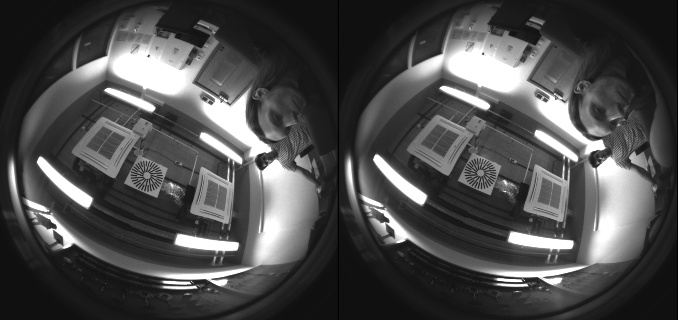


Przerwano działanie skryptu przez użytkownika.
Pipeline zatrzymany.


In [2]:
### TUTAJ WERSJA Z JPEGIEM MOZLIWE ZE MNIEJ DOKLADNA ALE BARDZIEJ WYDAJNA###
from IPython.display import display, clear_output, Image as IPythonImage

pipeline = rs.pipeline()
config = rs.config()

config.enable_stream(rs.stream.fisheye, 1, 848, 800, rs.format.y8, 30)
config.enable_stream(rs.stream.fisheye, 2, 848, 800, rs.format.y8, 30)
is_running = False

print("Uruchamianie kamery T265...")
time.sleep(1.0)

try:
    pipeline.start(config)
    is_running = True
    print("Pipeline OK. Kliknij przycisk stop, aby przerwać.")
    
    frame_count = 0
    
    while True:
        frames = pipeline.wait_for_frames()
        frame_count += 1
        
        if frame_count % 3 == 2:
            continue

        fisheye_frame1 = frames.get_fisheye_frame(1)
        fisheye_frame2 = frames.get_fisheye_frame(2)

        if not fisheye_frame1 or not fisheye_frame2:
            continue

        img1 = np.asanyarray(fisheye_frame1.get_data())
        img2 = np.asanyarray(fisheye_frame2.get_data())
        
        combined_img = np.hstack((img1, img2))
        small_img = cv2.resize(combined_img, (0, 0), fx=0.4, fy=0.4)
        
        _, encoded_img = cv2.imencode('.jpg', small_img)
        
        clear_output(wait=True)
        display(IPythonImage(data=encoded_img.tobytes()))
        
        time.sleep(0.01)

except KeyboardInterrupt:
    print("\nPrzerwano działanie skryptu przez użytkownika.")
except Exception as e:
    print("Error:", e)
finally:
    if is_running:
        pipeline.stop()
        print("Pipeline zatrzymany.")
    else:
        print("Pipeline nie został uruchomiony!")